In [8]:
# Libraries
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import pyarrow.dataset as ds
from collections import defaultdict
import pandas as pd

### Building R and X matrix for calculating Voltages later.

In [ ]:
## Building the R and X matrices for the linearized voltage model
## These are also sensitivity matrices for how load changes at each bus affect voltage at each bus, relative to the root bus.

def build_tree_from_lines(line_df, root=114):

    children = defaultdict(list)
    parent = {}
    edge_rx = {}

    for _, row in line_df.iterrows():
        i = int(row["upstream bus"])
        j = int(row["downstream bus"])
        r = float(row["series resistance (pu)"])
        x = float(row["series reactance (pu)"])

        children[i].append(j)
        parent[j] = i
        edge_rx[(i, j)] = (r, x)

    buses = sorted(set(line_df["upstream bus"]).union(set(line_df["downstream bus"])))
    non_root = [b for b in buses if b != root]

    return children, parent, edge_rx, buses, non_root


# It returns the list of edges on the path from a given bus to the root bus, in order from root to bus.
def path_edges_to_root(bus, parent):
    edges = []
    cur = bus
    while cur in parent:
        par = parent[cur]
        edges.append((par, cur))
        cur = par
    edges.reverse()
    return edges


def build_RX_matrices(line_df, root=0):
    
    children, parent, edge_rx, buses, non_root = build_tree_from_lines(line_df, root=root)
    n = len(non_root)

    bus_to_idx = {b: k for k, b in enumerate(non_root)}
    path_map = {b: path_edges_to_root(b, parent) for b in non_root}

    R = np.zeros((n, n), dtype=float)
    X = np.zeros((n, n), dtype=float)

    for bi in non_root:
        for bj in non_root:
            common = set(path_map[bi]).intersection(set(path_map[bj]))  # Only the common edges contribute to the voltage drop difference between bi and bj
            r_sum = sum(edge_rx[e][0] for e in common)
            x_sum = sum(edge_rx[e][1] for e in common)

            i = bus_to_idx[bi]
            j = bus_to_idx[bj]
            R[i, j] = 2.0 * r_sum
            X[i, j] = 2.0 * x_sum

    return R, X, non_root, bus_to_idx

In [12]:
line_df = pd.read_csv("IEEE123 lines.csv")
R, X, non_root, bus_to_idx = build_RX_matrices(line_df, root=114)

### Building Bus loads

In [116]:
dataset = ds.dataset("dataset", format="parquet")
table = dataset.to_table()
df = table.to_pandas()
df = df[['timestamp', 'out.electricity.net.energy_consumption']]



In [117]:
buses = sorted(set(line_df["upstream bus"]).union(set(line_df["downstream bus"]))) # removing the root bus
buses.remove(114)
bldgs = df.index.get_level_values("bldg_id").unique()

np.random.seed(0)

bus_assignment = pd.DataFrame({
    "bldg_id": bldgs,
    "bus": np.random.choice(buses, size=len(bldgs))
})

In [118]:
df.reset_index(inplace=True)

df = df.merge(bus_assignment, on="bldg_id")

bus_load = (
    df
    .groupby(["timestamp","bus"])["out.electricity.net.energy_consumption"]
    .sum()
    .reset_index()
)

In [119]:
bus_load = bus_load.pivot(
    index="timestamp",
    columns="bus",
    values="out.electricity.net.energy_consumption"
)

bus_load = bus_load.fillna(0)

# Forcing all the buses to  exist even if they have no load
bus_load = bus_load.reindex(columns=buses, fill_value=0.0)

In [120]:
## Bus load Preprocessing

bus_load = bus_load / 0.25

S_base = 5000 # 5000 kw / 5MW feeder rating.
bus_load = bus_load / S_base


### Hosting Capacity

In [121]:
def dynamic_hosting_capacity_network(
    load_bus_t,          # shape (T, n), positive loads
    R, X,                # shape (n, n)
    lhat_new,            # shape (T,)
    host_idx,            # integer index of host bus in ordering
    p0_bar,              # transformer limit
    v0=1.0,
    vmin=0.95,
    pf=0.9,
):
    T, n = load_bus_t.shape

    vmin = np.full(n, float(vmin))
    pf = np.full(n, float(pf))
    eta_bus = np.sqrt(1.0 / (pf ** 2) - 1.0)

    C_res = np.full(T, np.inf, dtype=float)
    C_dyn = np.full(T, np.inf, dtype=float)

    l_agg = load_bus_t.sum(axis=1)

    # Z = R + X diag(eta)
    Z = R + X @ np.diag(eta_bus)

    for t in range(T):
        ell = load_bus_t[t, :]

        # transformer headroom
        headroom_tx = p0_bar - l_agg[t]

        # voltage headroom
        numerator = v0 - vmin - 2.0 * (Z @ ell)
        denominator = 2.0 * Z[:, host_idx]

        valid = denominator > 1e-12
        if np.any(valid):
            headroom_v = np.min(numerator[valid] / denominator[valid])
        else:
            headroom_v = np.inf

        C_res[t] = min(headroom_tx, headroom_v)

        if lhat_new[t] > 1e-12:
            C_dyn[t] = C_res[t] / lhat_new[t]
        else:
            C_dyn[t] = np.inf

    return C_res, C_dyn

In [ ]:
def solve_cf_order_stat(C_dyn, C_res, lhat_new, K):
    active_idx = np.where(np.isfinite(C_dyn))[0]
    order = np.argsort(C_dyn[active_idx])
    
    C_star = C_dyn[active_idx][order[K]]
    critical_idx = active_idx[order[:K]]

    u_star = np.zeros_like(lhat_new, dtype=float)
    u_star[critical_idx] = C_res[critical_idx] - C_star * lhat_new[critical_idx]

    return C_star, critical_idx, u_star

In [ ]:
T = len(bus_load)
lhat = np.ones(T) # Normalized load

# candidate interconnection bus
host_bus_number = 13
host_idx = bus_to_idx[host_bus_number]

# limits
p0_bar = 1.0
v0 = 1.0
vmin = 0.95

C_res, C_dyn = dynamic_hosting_capacity_network(
    load_bus_t=bus_load.to_numpy(),
    R=R,
    X=X,
    lhat_new=lhat,
    host_idx=host_idx,
    p0_bar=p0_bar,
    v0=v0,
    vmin=vmin,
    pf=0.9,
)

# no flexibility hosting capacity
C0 = np.min(C_dyn[np.isfinite(C_dyn)])

# with K curtailment interventions
K = 350
C_star, critical_idx, u_star = solve_cf_order_stat(C_dyn, C_res, lhat, K)

print("Residual hosting capacity:", C0*5, "MW")
print("Hosting capacity with Curtailment:", C_star*5, "MW")
print("Number of curtailed slots:", len(critical_idx))

No-flex hosting capacity: 3.8888932560712868 MW
Hosting capacity with CF: 4.04708764339145 MW
Number of curtailed slots: 350


### Plotting

In [126]:
C_dyn

array([0.8912637 , 0.88945116, 0.88848987, ..., 0.86547675, 0.86352522,
       0.86785757], shape=(35040,))

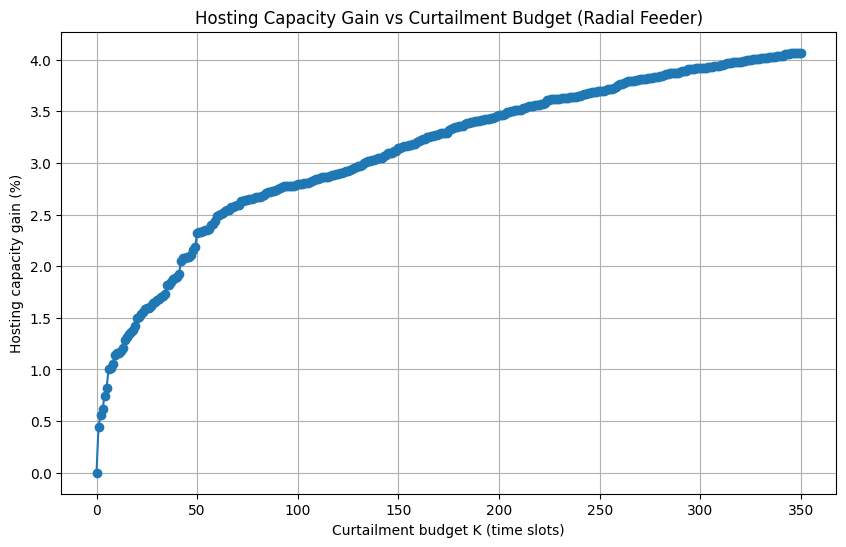

In [ ]:
# Removing values which has lhat 0
active_vals = C_dyn[np.isfinite(C_dyn)]


sorted_vals = np.sort(active_vals)
T_active = len(sorted_vals)
K = 350

# baseline hosting capacity
C0 = sorted_vals[0]


Ks = np.arange(K + 1)
Cstars = sorted_vals[Ks]

gains_pct = 100 * (Cstars - C0) / C0

plt.figure(figsize=(10,6))
plt.plot(Ks, gains_pct, marker='o')
plt.xlabel("Curtailment budget K (time slots)")
plt.ylabel("Hosting capacity gain (%)")
plt.title("Hosting Capacity Gain vs Curtailment Budget (Radial Feeder)")
plt.grid(True)
plt.show()